# Group Assignment: Time Series Analysis and Modeling
## Dataset: Monthly traffic fatalities in Ontario 1960-1974

In this notebook, we are going to perform a time series analysis of monthly traffic fatalities in Ontario. 
We have structured our work into 4 main parts:
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing
3. Model Selection and Fitting
4. Model Validation and Predictive Performance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings

# To avoid unnecessary warnings in the final notebook
warnings.filterwarnings("ignore")

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Reproducibility
SEED = 42
np.random.seed(SEED)

## 1. Exploratory Data Analysis (EDA)

The first thing we will do is load our data and take a look. The dataset contains monthly dates and the number of traffic fatalities.

In [2]:
# Load data
# my path (Guzman)
# file_path = '/home/gsantafe/Dropbox/01-Docencia/09-TimeSeries/quartoBook/Assessments/01_statisticalModels/10_Monthly traffic fatalities in Ontario 1960-1974.csv'
# original
file_path = 'data/10_Monthly traffic fatalities in Ontario 1960-1974.csv'
df = pd.read_csv(file_path)

# Let's look at the first few rows to understand the structure
display(df.head())

,date,deads
0,1960-01-01,61
1,1960-02-01,65
2,1960-03-01,55
3,1960-04-01,56
4,1960-05-01,91


As we can see, we have the `date` column and the `deads` (fatalities) column. 
We will convert the `date` column to a `datetime` format and set it as the index to facilitate time series analysis. Furthermore, we will check if there are missing months in the sequence.

In [3]:
# Convert to datetime
df['date'] = pd.to_datetime(df['date'])

# Check for missing months before setting it as the index
# To do this, we see how many months there should be between the start and end
expected_months = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='MS')
print(f"Expected months: {len(expected_months)}")
print(f"Current months in the dataset: {len(df)}")

missing_months = expected_months.difference(df['date'])
print(f"\nMissing months identified: {len(missing_months)}")
if len(missing_months) > 0:
    for m in missing_months:
        print(" -", m.strftime('%Y-%m'))

Expected months: 180
Current months in the dataset: 171

Missing months identified: 9
 - 1960-10
 - 1961-06
 - 1962-03
 - 1965-04
 - 1966-01
 - 1966-05
 - 1968-08
 - 1971-12
 - 1974-05


It looks like 9 months are missing, but none of the gaps are consecutive, they are always isolated single months. We will have to impute these values to have a continuous time series.
For now, let's set the date as the time index and plot the series as it is to identify **trend** and **seasonality**.

<span style="color: red;">You should set the frequency to monthly to account for the gaps where missing values are located and visualize them in the plot.</span>

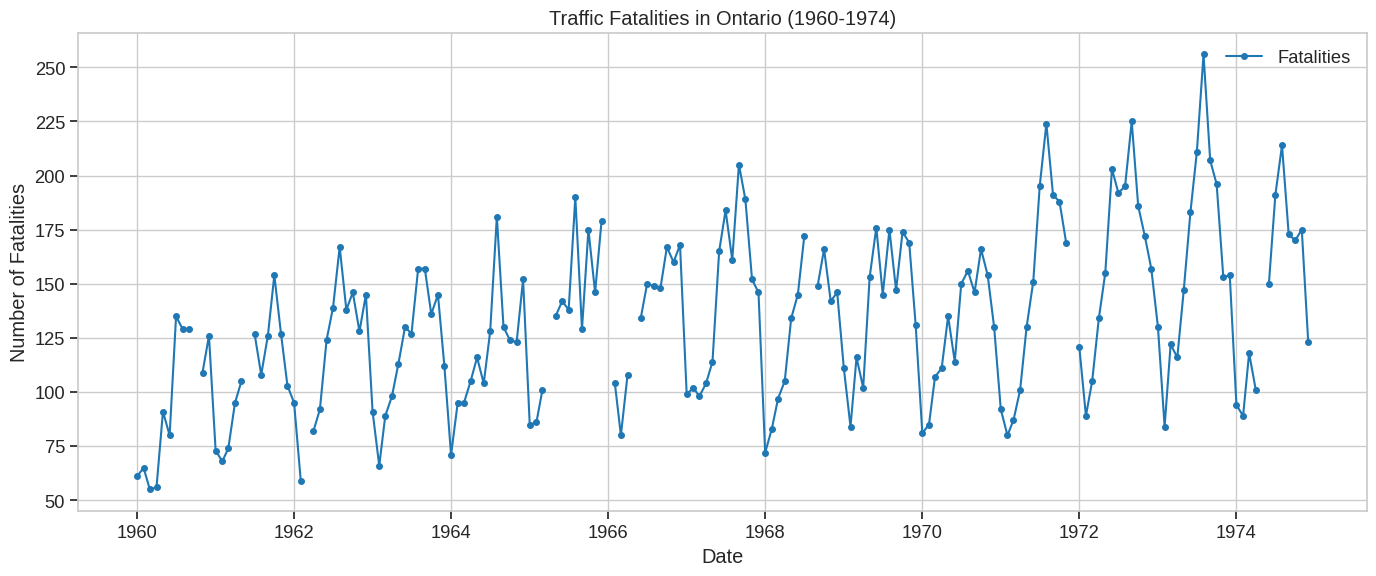

In [4]:
# Set date as the index
df.set_index('date', inplace=True)
df = df.asfreq('MS') # FIXED

# Initial time series visualization
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['deads'], marker='o', linestyle='-', markersize=4, label='Fatalities')
plt.title('Traffic Fatalities in Ontario (1960-1974)')
plt.xlabel('Date')
plt.ylabel('Number of Fatalities')
plt.legend()
plt.tight_layout()
plt.show()


### 1.1 Imputar valores

Imputamos los valores primero:

To be able to apply models like ARIMA or SARIMA, we need the series to be equally spaced in time without interruptions.

Given that the series has strong seasonality and that missing months are isolated, a simple linear interpolation would be enough.

<span style="color: red">Why is linear interpolation sufficient? Have you tried any other imputation methods? You could try different methods to evaluate whether there are differences and then choose the best one...</span>

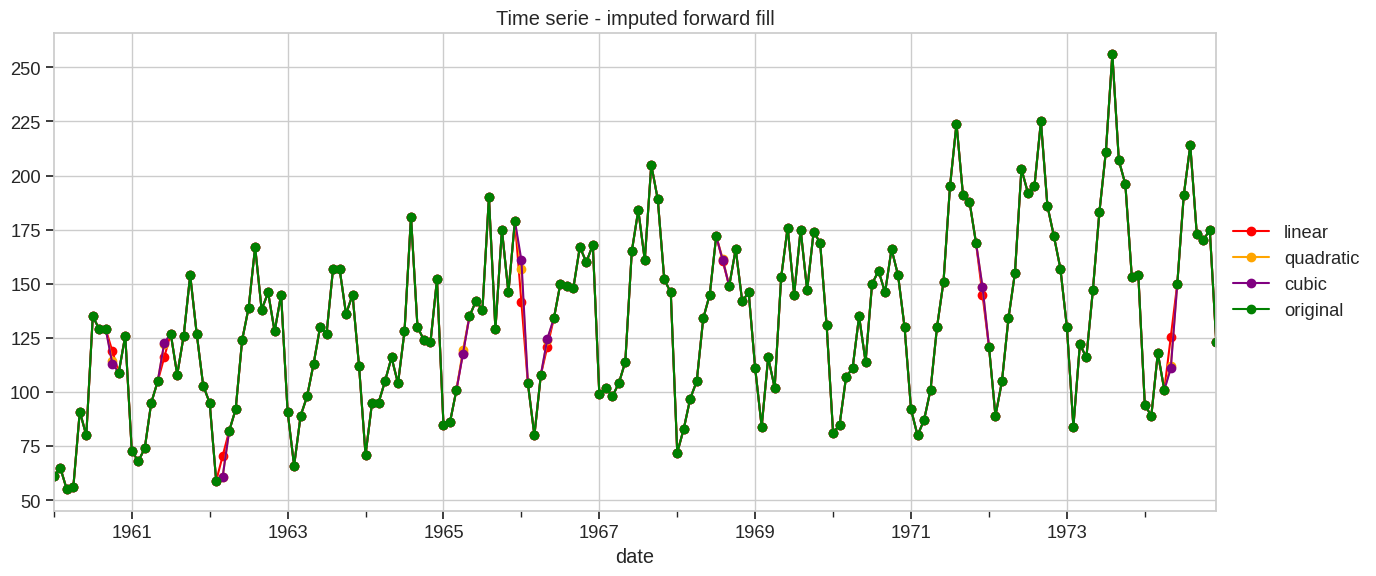

In [5]:
data_imputed = df.copy()
data_imputed['deads'] = data_imputed['deads'].interpolate(method = 'linear')

data_imputed_2 = df.copy()
data_imputed_2['deads'] = data_imputed_2['deads'].interpolate(method = 'quadratic')

data_imputed_3 = df.copy()
data_imputed_3['deads'] = data_imputed_3['deads'].interpolate(method = 'cubic')

fig, ax = plt.subplots(figsize=(14, 6))

data_imputed['deads'].plot(ax=ax, label='linear', color="red", marker='o')
data_imputed_2['deads'].plot(ax=ax, label='quadratic', color="orange", marker='o')
data_imputed_3['deads'].plot(ax=ax, label='cubic', color="purple", marker='o')
df['deads'].plot(ax=ax, label='original',color="green", marker='o')

# data_incomplete['deads'].plot(ax=ax, label="incomplete", color="blue")

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title("Time serie - imputed forward fill")
plt.tight_layout() 
plt.show()

### 1.2 Analizar Descomposición

Analizamos la descomposición

In [6]:
df = data_imputed

#### 1.2.1 Clasico

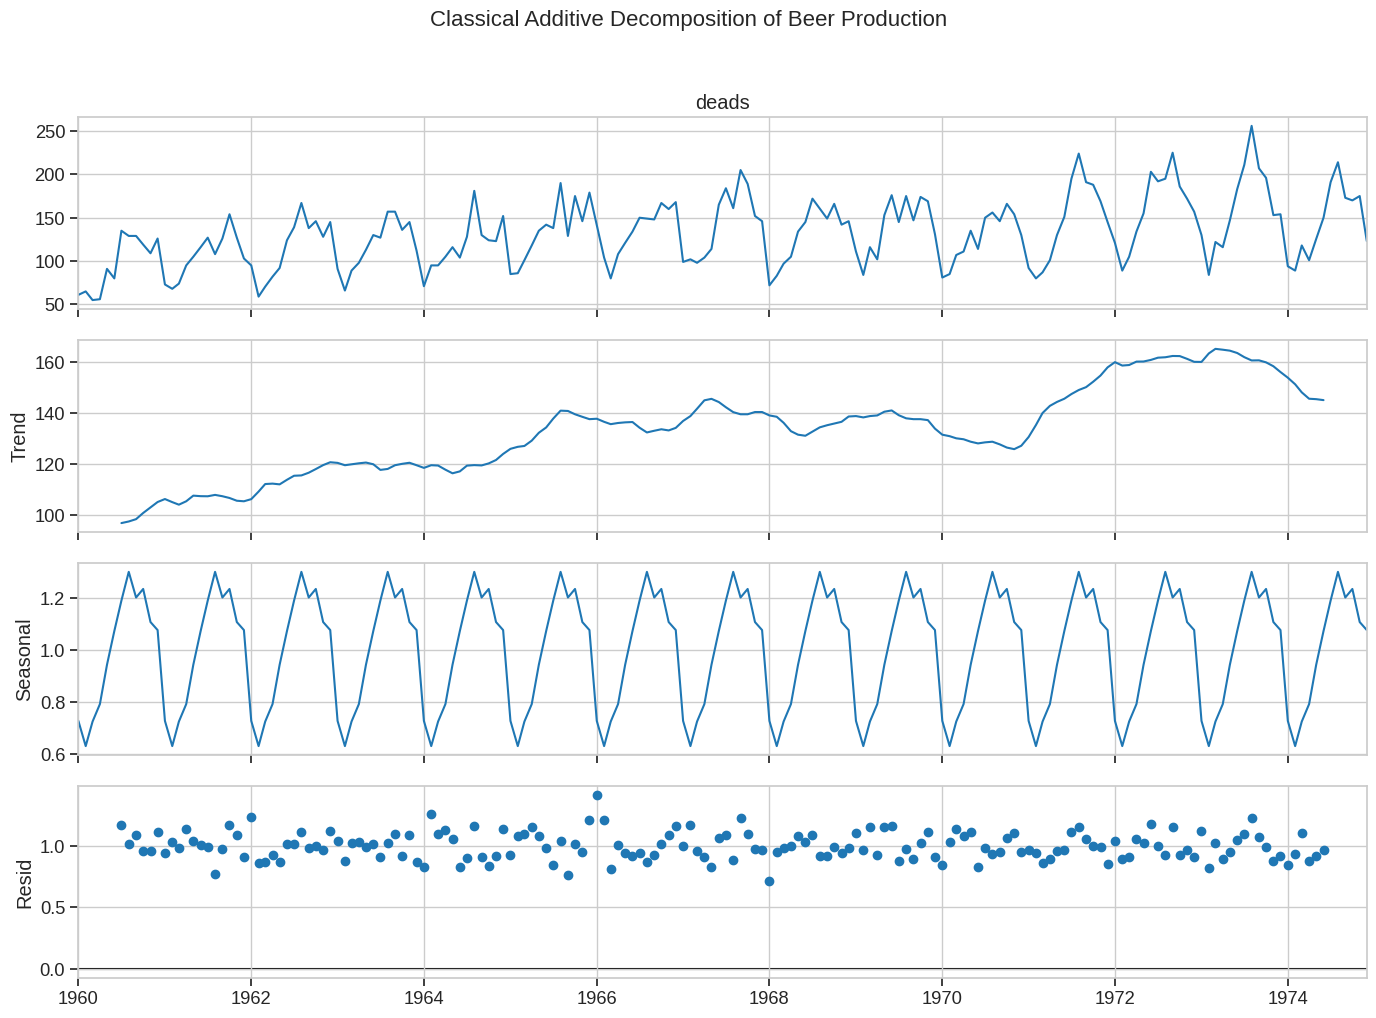

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# ---------------------------------------------------------
# 2. Classical Decomposition
# ---------------------------------------------------------
# Apply seasonal decomposition using moving averages.
# Parameters:
#   - model='additive'
#   - period=4: Defines the seasonal span (Quarterly data)
result = seasonal_decompose(df['deads'], model='multiplicative', period=12)

# ---------------------------------------------------------
# 3. Visualization and Results
# ---------------------------------------------------------
# Plot the four components: Observed, Trend, Seasonal, and Residual.

# No necesitas crear 'fig, ax' antes, statsmodels lo hace por ti.
# Simplemente llama al método plot() directamente.
fig = result.plot()

# Ajustamos el tamaño de la figura generada
fig.set_size_inches(14, 10)

# Añadimos el título (usamos y=1.02 para que no choque con los gráficos)
plt.suptitle("Classical Additive Decomposition of Beer Production", fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

#### 1.2.2 STL

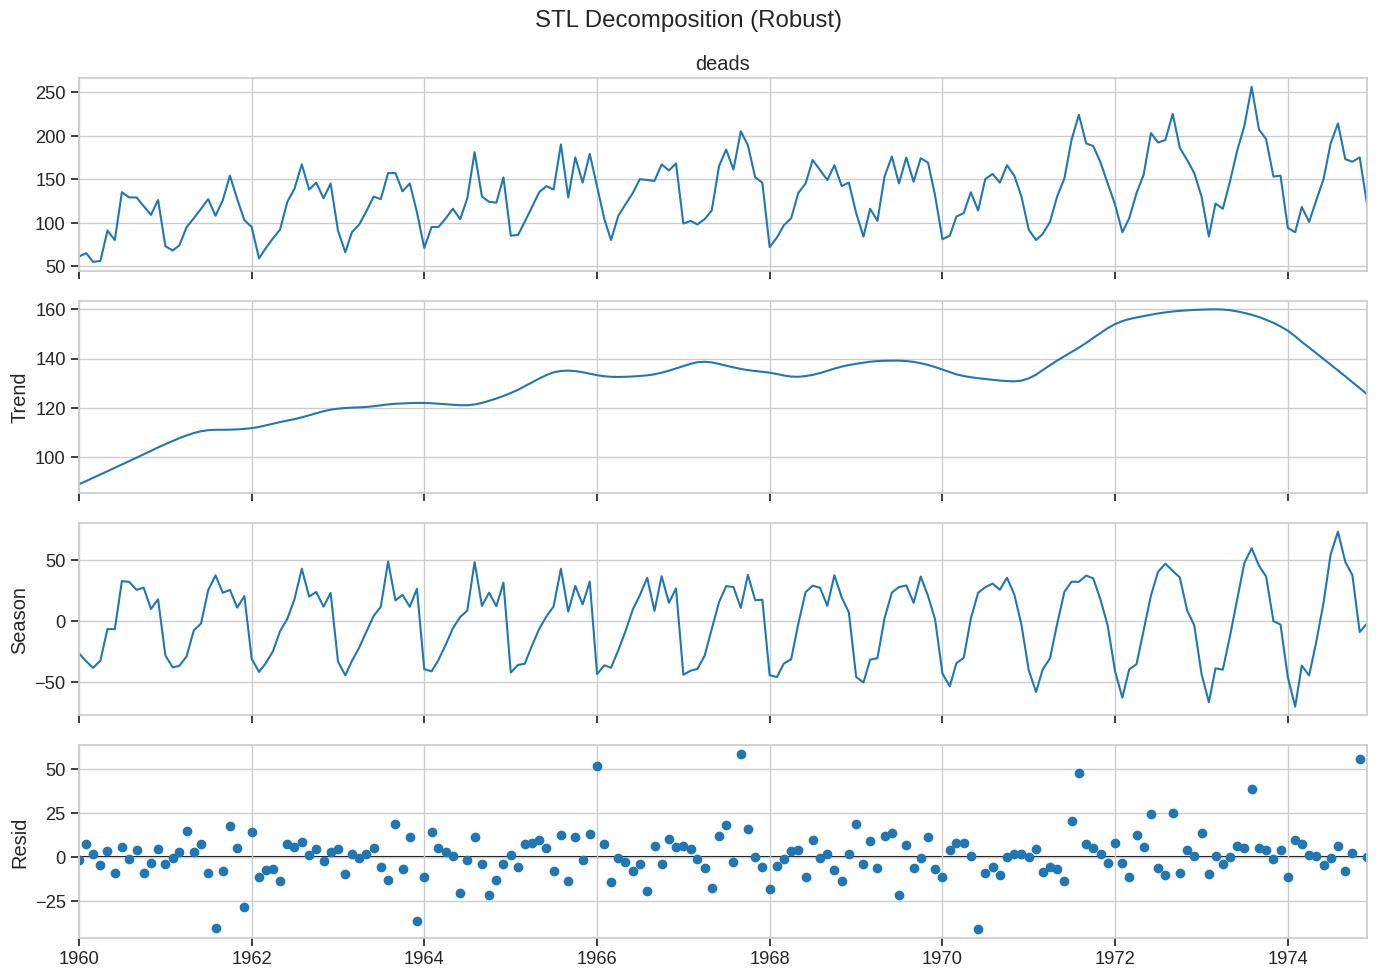

In [8]:
from statsmodels.tsa.seasonal import STL

# ---------------------------------------------------------
# 1. STL Model Definition
# ---------------------------------------------------------
# Initialize the STL model (Seasonal-Trend decomposition using LOESS).
# This is preferred in modern analysis over classical decomposition due to its robustness.
# Parameters:
#   - period=4: Quarterly seasonality.
#   - robust=True: Reduces the influence of outliers (similar to robust features in fable).
stl = STL(df['deads'], period=12, robust=True)

# Fit the model to the data
res_stl = stl.fit()

# ---------------------------------------------------------
# 2. Visualization and Results
# ---------------------------------------------------------
fig = res_stl.plot()

# Ajustamos el tamaño de la figura generada
fig.set_size_inches(14, 10)
plt.suptitle("STL Decomposition (Robust)")
plt.tight_layout()
plt.show()

At first glance, it seems that:
1. **Trend**: There is a slight upward trend. Accidents increase as the years progress, possibly linked to a greater number of cars on the roads between the 60s and 70s.
2. **Seasonality**: Regular peaks and valleys are noticeable, with a 12 month pattern. We can see that more accidents happen in summer, when people travel for holidays. We will verify this in more detail later.
3. **Variance**: The variance of the cycles also seems to be slightly increasing over time. This makes us think we might need to stabilize the variance (perhaps using a logarithmic transformation) before modeling.

### 1.3 Stationarity Evaluation

To statistically check the stationarity of the original series (although visually we know it is not, due to the trend and variance), we will apply the ADF test.

<span style="color: red;"> You only use ADF test. Usually both test ADF and KPSS are used to assess stationarity</spam>

In [9]:
from statsmodels.tsa.stattools import adfuller, kpss
import pandas as pd
import numpy as np

def test_stationarity(timeseries, ct=True, title=""):
    # --- Clean the series first ---
    timeseries = timeseries.replace([np.inf, -np.inf], np.nan).dropna()

    print(f"--- ADF Test Results {title} ---")
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(
        dftest[0:4],
        index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used']
    )
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
    print(dfoutput)

    if dftest[1] <= 0.05:
        print("\nConclusion: We reject H0. The series IS STATIONARY.")
    else:
        print("\nConclusion: We cannot reject H0. The series is NOT STATIONARY.")

    # --- KPSS Test ---
    regression = 'ct' if ct else 'c'
    result_kpss = kpss(timeseries, regression=regression, nlags='auto')

    print(f"\n{'='*65}")
    print(f"KPSS Test: {'Trend Stationarity' if ct else 'Level Stationarity'}")
    print('='*65)
    print(f"Test Statistic:         {result_kpss[0]:.4f}")
    print(f"P-value:                {result_kpss[1]:.4f}")   # was result_stationary (undefined)
    print(f"Lags Used:              {result_kpss[2]}")        # was result_stationary (undefined)
    for key, value in result_kpss[3].items():
        print(f"Critical Value ({key}):  {value:.4f}")

    if result_kpss[1] < 0.05:
        print("\nKPSS Conclusion: We reject H0. The series is NOT STATIONARY.")
    else:
        print("\nKPSS Conclusion: We cannot reject H0. The series IS STATIONARY.")

test_stationarity(df['deads'], title="for Original Series")
# test_stationarity(df['deads'], ct = False, title="for Original Series")

--- ADF Test Results for Original Series ---
Test Statistic                  -1.842874
p-value                          0.359393
#Lags Used                      11.000000
Number of Observations Used    168.000000
Critical Value (1%)             -3.469886
Critical Value (5%)             -2.878903
Critical Value (10%)            -2.576027
dtype: float64

Conclusion: We cannot reject H0. The series is NOT STATIONARY.

KPSS Test: Trend Stationarity
Test Statistic:         0.0470
P-value:                0.1000
Lags Used:              6
Critical Value (10%):  0.1190
Critical Value (5%):  0.1460
Critical Value (2.5%):  0.1760
Critical Value (1%):  0.2160

KPSS Conclusion: We cannot reject H0. The series IS STATIONARY.


## 2. Data Preprocessing

After applied this preproccesing, the series is now continuous.
Additionally, we had detected that the variance increased slightly over time. Let's apply the **Box-Cox transformation** to stabilize the variance.

### 2.1 Transformaciones Box-Cox

In [10]:
import numpy as np
import pandas as pd
from scipy import stats

# -------------------------------------------------------------------------
# Custom Implementation of Guerrero's Method (Guerrero, V. M. ,1993)
# Goal: Find lambda that minimizes the Coefficient of Variation of the 
#       standard deviation over rolling windows.
# -------------------------------------------------------------------------
def guerrero_lambda(series, min_lambda=-2, max_lambda=2, window_size=24):
    """
    Estimates the optimal Box-Cox lambda using the Guerrero method.
    """
    series_clean = series.copy()
    # Box-Cox requires strictly positive data
    if series_clean.min() <= 0:
        series_clean += np.abs(series_clean.min()) + 1
        
    # lambdas = np.round(np.arange(min_lambda, max_lambda, 0.1), 1) # Search range
    lambdas = np.arange(min_lambda, max_lambda, 0.1) # Search range
    cvs = [] # To store Coefficient of Variation
    
    for l in lambdas:
        # Apply transformation
        if l == 0:
            trans_data = np.log(series_clean)
        else:
            trans_data = (series_clean**l - 1) / l
        
        # Calculate rolling standard deviation
        s_trans = pd.Series(trans_data)
        roll_std = s_trans.rolling(window_size).std()
        
        # Calculate CV of the rolling std (Spread of the spread)
        valid_std = roll_std.dropna()
        cv = valid_std.std() / valid_std.mean()
        cvs.append(cv)
    
    # Return lambda that minimizes the variation of variance
    return np.round(lambdas[np.argmin(cvs)],1)

In [11]:
df_resampled = df.copy()

In [12]:
from scipy.stats import boxcox, boxcox_normmax

## Apply Box-Cox transformation - Guerrero
# find optimal lambda (as fecuency is monthly, we use a 2 years rolling window)
lambda_guerrero = guerrero_lambda(df_resampled['deads'], window_size=24) 
series_boxcox_guerrero = boxcox(df_resampled['deads'], lmbda=lambda_guerrero)
print(f"Optimal Box-Cox λ - Guerrero: {lambda_guerrero:.1f}")

## Apply Box-Cox transformation - MLE
# find optimal lambda (as fequency is monthly, we use a 2 years rolling window)
series_boxcox_mle, lambda_mle = boxcox(df_resampled['deads'])
print(f"Optimal Box-Cox λ - MLE: {lambda_mle:.1f}")

Optimal Box-Cox λ - Guerrero: -0.1
Optimal Box-Cox λ - MLE: 0.5


The primary goal of Guerrero method is to specifically stabilize variance. And as we are getting a lamba value close to 0, we will finally apply **logarithmic transformation** because it is simpler and more interpretable.

In [13]:
df_resampled = df.copy()

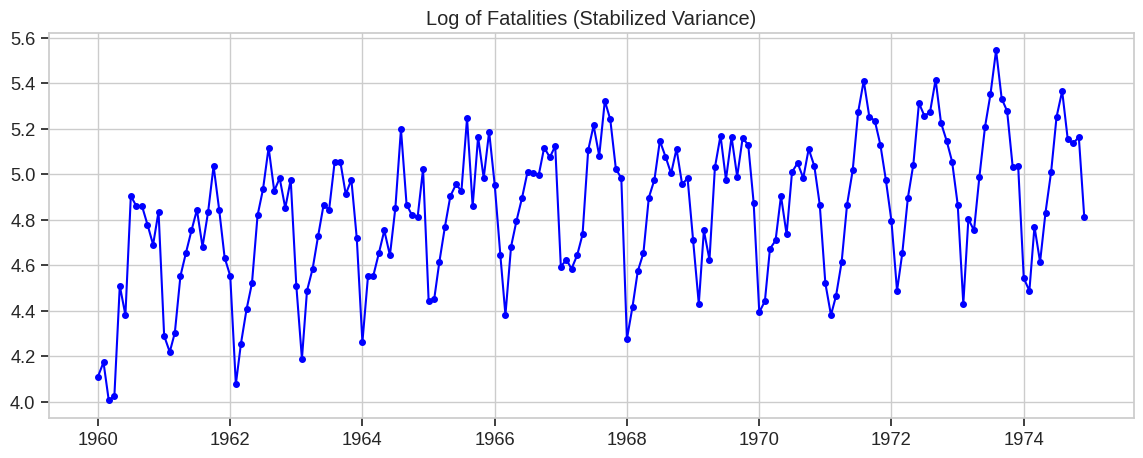

In [14]:
# Logarithmic transformation to stabilize variance
df_resampled['log_deads'] = np.log(df_resampled['deads'])

plt.figure(figsize=(14, 5))
plt.plot(df_resampled.index, df_resampled['log_deads'], marker='o', markersize=4, color='blue')
plt.title('Log of Fatalities (Stabilized Variance)')
plt.show()

### 2.2 Analizar normalidad de los datos

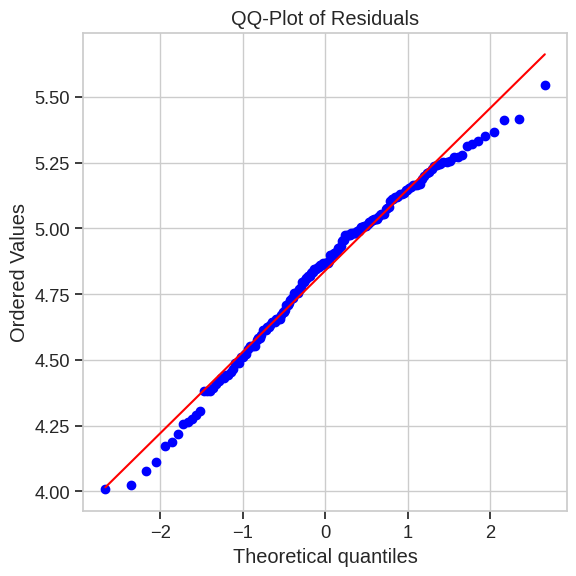

Shapiro-Wilk: stat=0.9830, p=0.0276
KS Test corregido: stat=0.0780, p=0.2126
Jarque-Bera: stat=5.6299, p=0.0599


In [25]:
import scipy.stats as stats
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(df_resampled['log_deads'], dist="norm", plot=ax)
ax.set_title("QQ-Plot of Residuals")
plt.tight_layout()
plt.show()

from scipy.stats import shapiro
stat, p = shapiro(df_resampled['log_deads'])
print(f"Shapiro-Wilk: stat={stat:.4f}, p={p:.4f}")
# p > 0.05 → no se rechaza normalidad

from scipy.stats import kstest
data = df_resampled['log_deads']
stat, p = kstest((data - data.mean()) / data.std(), 'norm')
print(f"KS Test corregido: stat={stat:.4f}, p={p:.4f}")

from scipy.stats import jarque_bera
stat, p = jarque_bera(df_resampled['log_deads'])
print(f"Jarque-Bera: stat={stat:.4f}, p={p:.4f}")

* Shapiro-Wilk → p = 0.027 → rechaza normalidad, pero por muy poco y con muestras grandes tiende a ser hiper-sensible
* KS corregido → p = 0.213 > 0.05 → no rechaza normalidad ✓
* Jarque-Bera → p = 0.059 > 0.05 → no rechaza normalidad ✓

### 2.3 Descomponer la serie nuevamente

Next, we will decompose the series to isolate and visually confirm the **Trend** and **Seasonality** components.

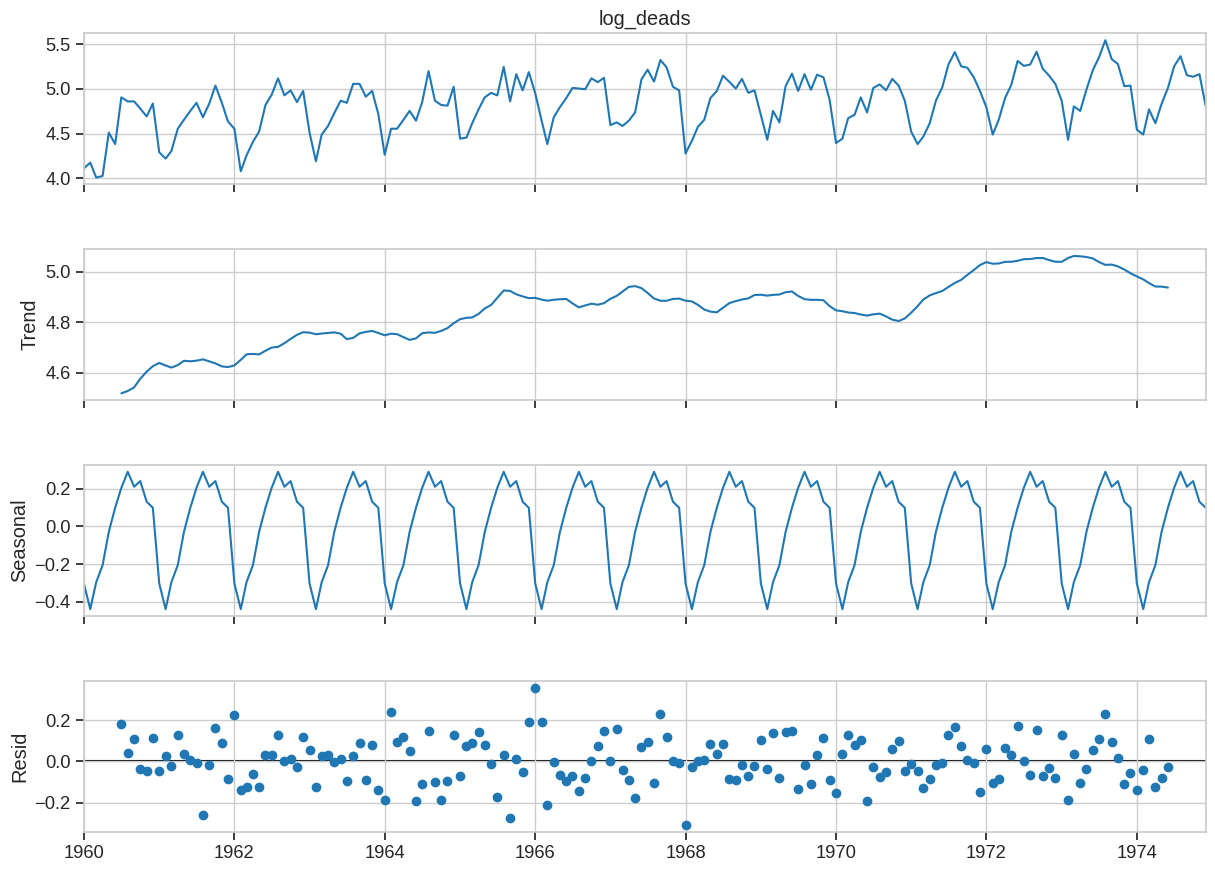

In [26]:
# Time series decomposition
decomposition = seasonal_decompose(df_resampled['log_deads'], model='additive')

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

In [27]:
test_stationarity(df_resampled['log_deads'], title="for Original Series")

--- ADF Test Results for Original Series ---
Test Statistic                  -2.323726
p-value                          0.164430
#Lags Used                      11.000000
Number of Observations Used    168.000000
Critical Value (1%)             -3.469886
Critical Value (5%)             -2.878903
Critical Value (10%)            -2.576027
dtype: float64

Conclusion: We cannot reject H0. The series is NOT STATIONARY.

KPSS Test: Trend Stationarity
Test Statistic:         0.0780
P-value:                0.1000
Lags Used:              6
Critical Value (10%):  0.1190
Critical Value (5%):  0.1460
Critical Value (2.5%):  0.1760
Critical Value (1%):  0.2160

KPSS Conclusion: We cannot reject H0. The series IS STATIONARY.


The seasonal decomposition confirms our suspicions:
- There is a clear annual upward trend.
- There is a perfect cyclical seasonality (every 12 months).

This indicates that a **SARIMA** model will be the most suitable candidate, as it accounts for both the non-seasonal and strongly seasonal components.

### 2.4 Analizar Diferenciación. Primero seasonal -> luego regular

In order to use SARIMA, we need to make the series stationary, so we will difference the series. First, a regular difference, and then a seasonal difference (m=12).

<span style="color: red">The order of differentiation matters; you should apply the seasonal difference before the regular difference!! Furthermore, you should check whether the series has reached stationarity after the seasonal difference is applied. It is possible that a regular difference may not be necessary.</span>

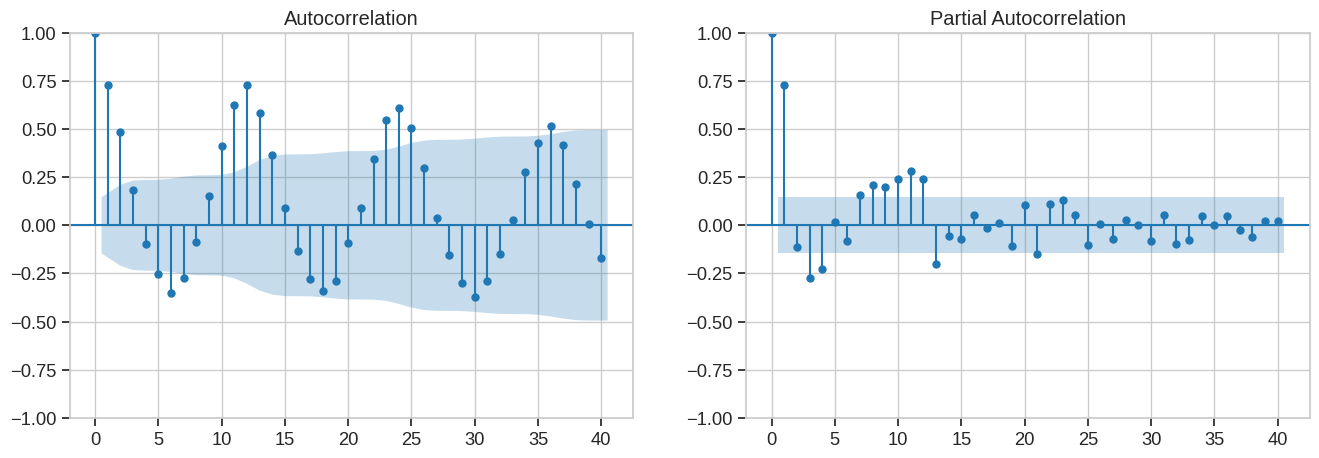

In [28]:
# test_stationarity(df_diff, title="for Differenced Series (d=1, D=1)")

# Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df_resampled['log_deads'], ax=axes[0], lags=40)
plot_pacf(df_resampled['log_deads'], ax=axes[1], lags=40)
plt.show()

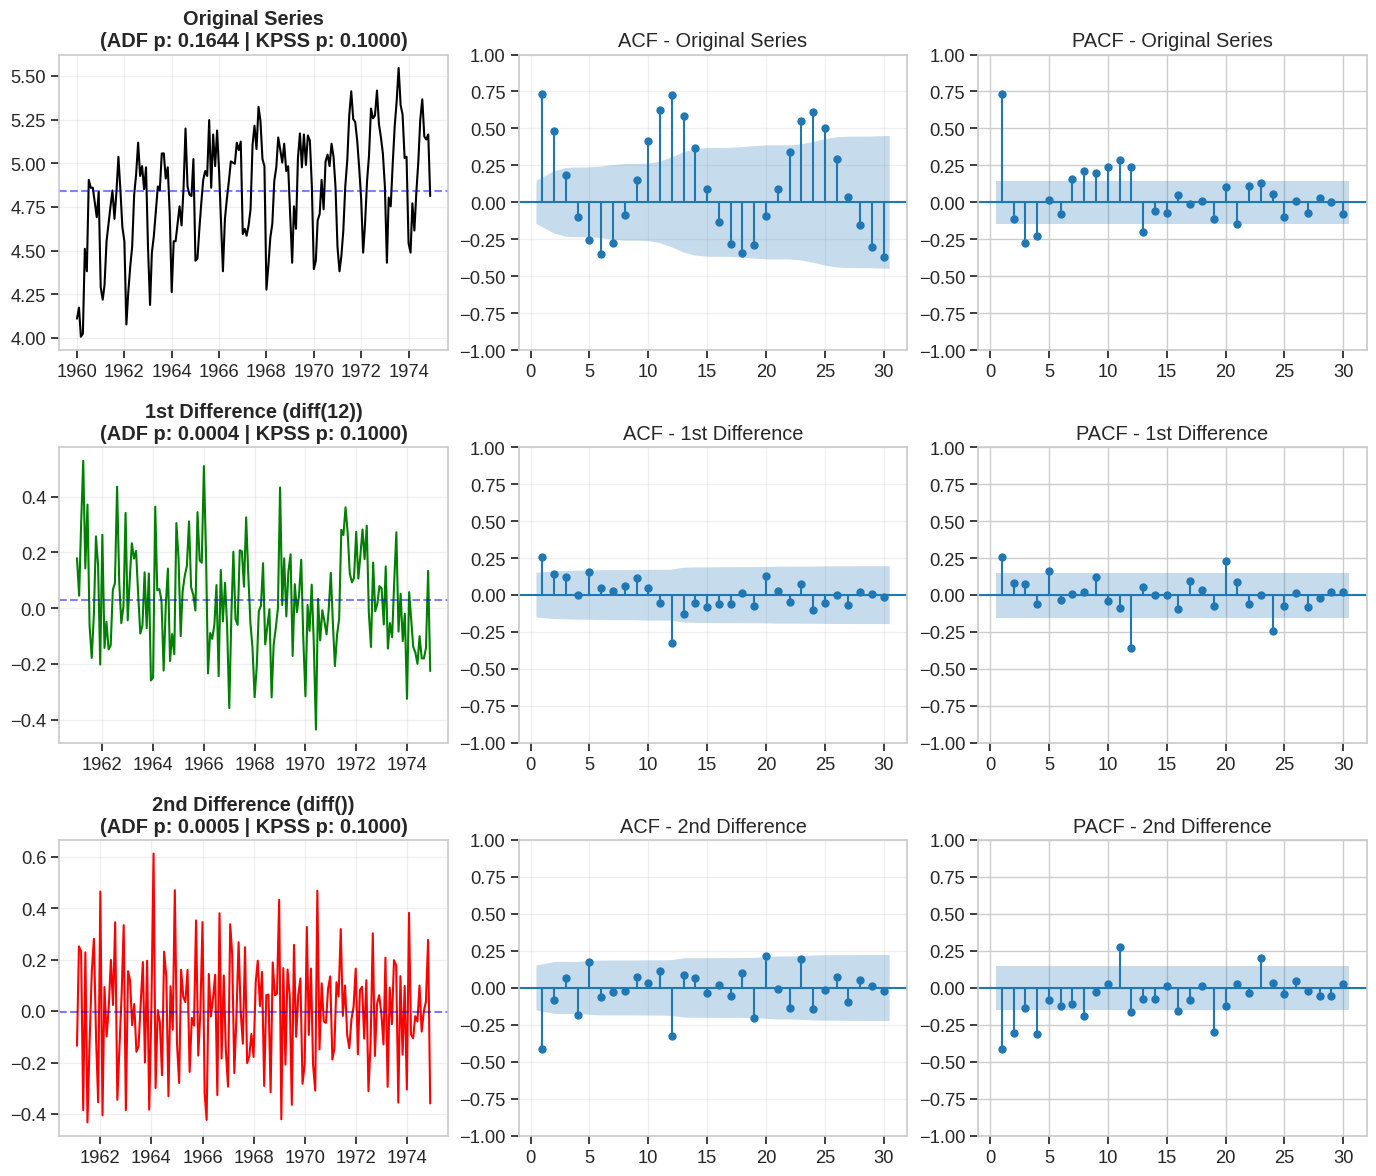

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# 2. Apply Differencing
# -----------------------------------------------------------------------------
series = df_resampled['log_deads']
# diff1 = series.diff().dropna()
diff1 = series.diff(periods=12).dropna()
diff2 = diff1.diff().dropna()

datasets = [
    ('Original Series', series, 'black'),
    ('1st Diff (d=1)', diff1, 'green'),
    ('2nd Diff (d=2)', diff2, 'red')
]

# -----------------------------------------------------------------------------
# 3. Compute Statistical Tests 
# -----------------------------------------------------------------------------
# Original Series
adf_orig = adfuller(series.dropna())[1]
kpss_orig = kpss(series.dropna(), regression='ct', nlags="auto")[1]

# First Difference (d=1)
adf_d1 = adfuller(diff1)[1]
kpss_d1 = kpss(diff1, regression='ct', nlags="auto")[1]

# Second Difference (d=2)
adf_d2 = adfuller(diff2)[1]
kpss_d2 = kpss(diff2, regression='ct', nlags="auto")[1]

# -----------------------------------------------------------------------------
# 4. Visualization (Step-by-step)
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

# --- ROW 1: ORIGINAL SERIES ---
# Line Plot
axes[0, 0].plot(series, color='black')
axes[0, 0].set_title(f"Original Series\n(ADF p: {adf_orig:.4f} | KPSS p: {kpss_orig:.4f})", fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=series.mean(), color='blue', linestyle='--', alpha=0.5)

# ACF Plot
plot_acf(series, ax=axes[0, 1], lags=30, title='ACF - Original Series', zero=False)
plot_pacf(series, ax=axes[0, 2], lags=30, title='PACF - Original Series', zero=False)
axes[0, 1].grid(True, alpha=0.3)


# --- ROW 2: FIRST DIFFERENCE (d=1) ---
# Line Plot
axes[1, 0].plot(diff1, color='green')
axes[1, 0].set_title(f"1st Difference (diff(12))\n(ADF p: {adf_d1:.4f} | KPSS p: {kpss_d1:.4f})", fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=diff1.mean(), color='blue', linestyle='--', alpha=0.5)

# ACF Plot
plot_acf(diff1, ax=axes[1, 1], lags=30, title='ACF - 1st Difference', zero=False)
plot_pacf(diff1, ax=axes[1, 2], lags=30, title='PACF - 1st Difference', zero=False)
axes[1, 1].grid(True, alpha=0.3)


# --- ROW 3: SECOND DIFFERENCE (d=2) ---
# Line Plot
axes[2, 0].plot(diff2, color='red')
axes[2, 0].set_title(f"2nd Difference (diff())\n(ADF p: {adf_d2:.4f} | KPSS p: {kpss_d2:.4f})", fontweight='bold')
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].axhline(y=diff2.mean(), color='blue', linestyle='--', alpha=0.5)

# ACF Plot
plot_acf(diff2, ax=axes[2, 1], lags=30, title='ACF - 2nd Difference', zero=False)
plot_pacf(diff2, ax=axes[2, 2], lags=30, title='PACF - 2nd Difference', zero=False)
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# SARIMAX(0,1,1)(2,1,0,12) 

In [ ]:
# D = 1, m = 12, d = 0, 

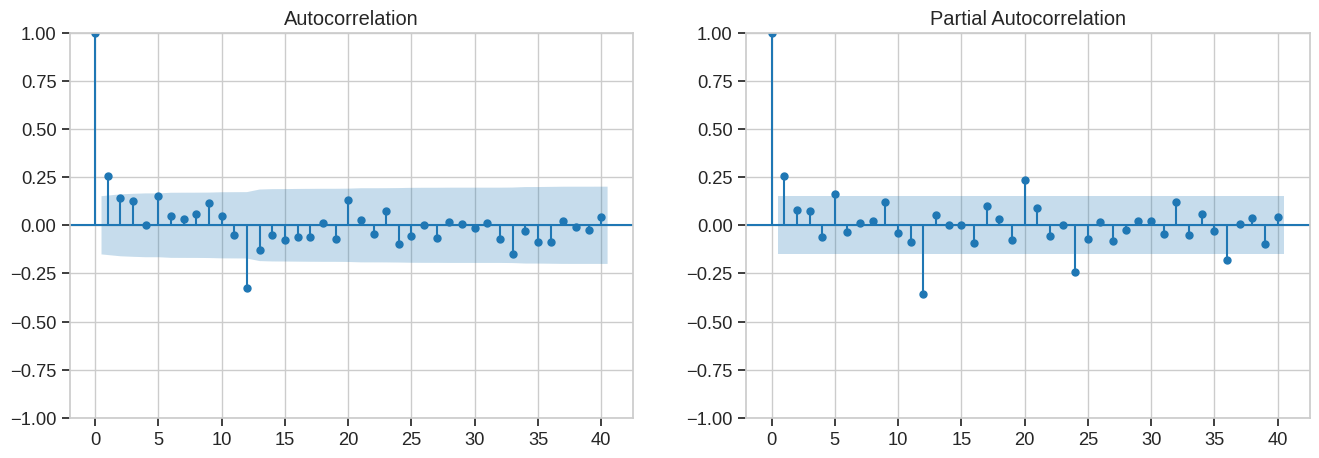

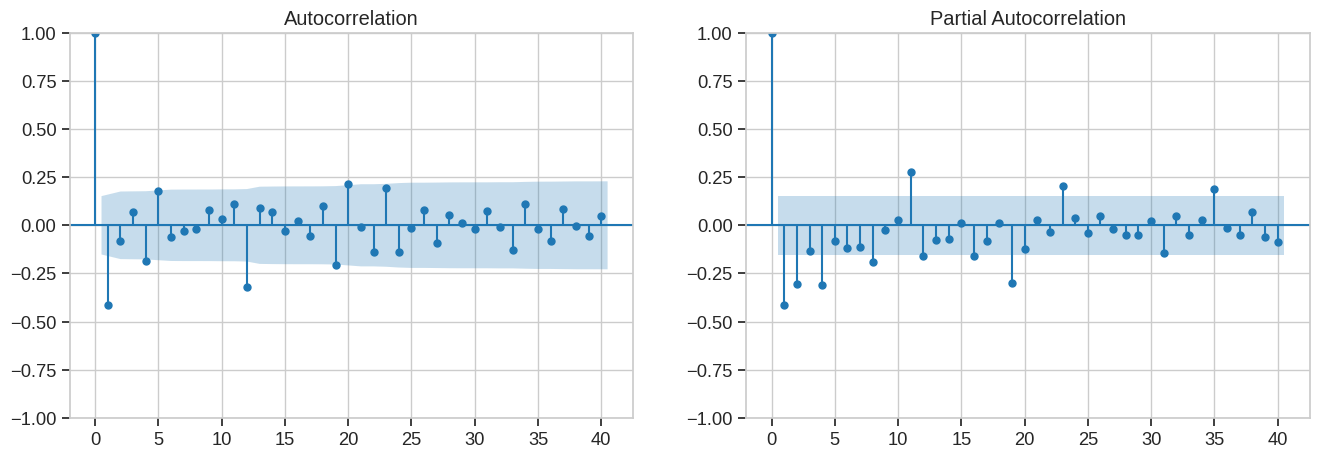

In [44]:
# test_stationarity(df_diff, title="for Differenced Series (d=1, D=1)")

# Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots
# diff1 = series.diff(periods=12).dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(diff1, ax=axes[0], lags=40)
plot_pacf(diff1, ax=axes[1], lags=40)
plt.show()

# diff2 = diff1.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(diff2, ax=axes[0], lags=40)
plot_pacf(diff2, ax=axes[1], lags=40)
plt.show()

# SARIMA = (p, d, q) x (P, D, Q)m
# D = 1, m = 12, d = 0, q = 1, p = 1, Q = 1, P = 1


<span style="color: red"> You should also use the KPSS test. Additionally, it is useful to re-examine the series plot after differentiation. An analysis of the ACF and PACF functions should reveal information regarding the AR and MA orders.</span>

Los test indican que con una diferenciación sería suficiente. Además:

1) Reglas de lectura ACF/PACF:

* ACF corta bruscamente en lag k → sugiere MA(k)
* PACF corta bruscamente en lag k → sugiere AR(k)
Ambas decaen gradualmente → mezcla AR+MA


2) Plot 1 — tras diff(12):

* ACF → pico significativo en lag 1, luego cae → sugiere MA(1)
* ACF → pico negativo notable en lag 12 → sugiere SMA(1)
* PACF → pico en lag 1, decae gradualmente → consistente con MA
* PACF → pico negativo en lag 12 → consistente con SMA

→ Propuesta: ARIMA(0,0,1)(0,1,1,12)

3) Plot 2 — tras diff(12) + diff():

* ACF → caída brusca negativa en lag 1 → MA(1)
* PACF → también cae en lag 1 negativamente → podría haber sobrediferenciado (señal clásica)
* Lag 12 menos pronunciado que en imagen 1

→ Propuesta: ARIMA(0,1,1)(0,1,1,12)

⚠️ Ojo, importante:

El pico negativo fuerte en lag 1 del ACF de la imagen 2 es señal clásica de sobrediferenciación. Puede que con d=1 y D=1 estés diferenciando de más, lo que introduce MA artificialmente.

Compara AIC de ambos modelos y vigila ese lag 1.

## 3. Model Selection and Fitting

Now that we have the series ready, we proceed to split our data into Train and Test sets. If we look closely to the time series, we can observe how in 1971 there is a little change on the amplitude of the series. So, instead of using a 80/20 split (36 month for testing), we will only use the last 24 months for testing. This way we will keep almost two full seasons of the series (1971 and 1972) to model the change on the behaviour.

Train set size: 156
Test set size: 24


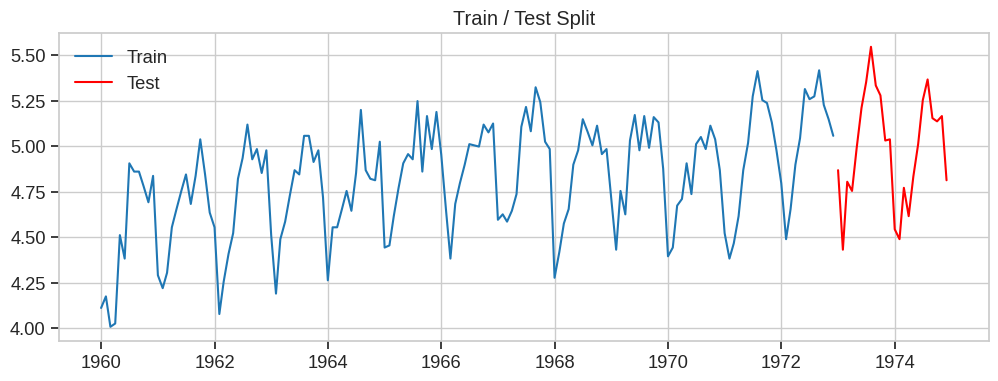

In [45]:
# Train-Test Split (last 24 months as Test)
train_size = len(df_resampled) - 24
train, test = df_resampled['log_deads'].iloc[:train_size], df_resampled['log_deads'].iloc[train_size:]

print(f"Train set size: {len(train)}")
print(f"Test set size: {len(test)}")

plt.figure(figsize=(12, 4))
plt.plot(train, label='Train')
plt.plot(test, label='Test', color='red')
plt.legend()
plt.title('Train / Test Split')
plt.show()

To find the best parameter fit `(p,d,q) x (P,D,Q,m)`, we could use the correlograms analyzed previously. However, we will use the `pmdarima` library (AutoARIMA) to perform an exhaustive search for the best model based on the Akaike Information Criterion (AIC). We will pass it the `log_deads` series and tell it to look for seasonality with m=12.

<span style="color: red">Using the pmdarima automated method does not exempt you from analyzing the ACF and PACF plots. These functions provide critical information for assessing the potential orders of AR and MA processes, allowing you to evaluate the results obtained from auto_arima with a critical eye.</span>

### 3.1 Auto ARIMA

In [46]:
import pmdarima as pm

# Auto ARIMA to find the best SARIMA on the Log of the data
# We already know it will need D=1, d=1 since we achieved stationarity with them in previous analyses
auto_model = pm.auto_arima(train, 
                           start_p=0, start_q=0,
                           max_p=3, max_q=3, 
                           m=12,
                           start_P=0, start_Q=0,
                           max_P=2, max_Q=2,
                           seasonal=True,
                           d=1, D=1, 
                           trace=True,
                           error_action='ignore',  
                           suppress_warnings=True, 
                           stepwise=True,
                           random_state=SEED)

print("\n--- Best selected model summary ---")
print(auto_model.summary())
# (1, 0, 1)(1, 1, 1, 12)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-24.009, Time=0.33 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-65.528, Time=0.23 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=0.69 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=-45.628, Time=0.04 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=-76.913, Time=0.26 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=1.34 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=0.41 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=-50.492, Time=0.19 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=-91.580, Time=0.32 sec
 ARIMA(2,1,0)(1,1,0)[12]             : AIC=-78.395, Time=0.14 sec
 ARIMA(2,1,0)(2,1,1)[12]             : AIC=inf, Time=1.42 sec
 ARIMA(2,1,0)(1,1,1)[12]             : AIC=inf, Time=0.65 sec
 ARIMA(3,1,0)(2,1,0)[12]             : AIC=-90.489, Time=0.42 sec
 ARIMA(2,1,1)(2,1,0)[12]             : AIC=-108.315, Time=0.74 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=-98.121, 

AutoARIMA has found the model with the lowest AIC. Now let's analyze the residuals of the best model to validate it.

<span style="color: red">Although auto_arima selected the SARIMAX(1,1,1)(2,1,0,12) model based on the lowest AIC, a closer inspection of the coefficients reveals that the non-seasonal autoregressive term (ar.L1) is not statistically significant ($p = 0.113 > 0.05$). This suggests the model may be over-parameterized. The highly significant Moving Average term (ma.L1, $p < 0.001$) is likely capturing most of the short-term dynamics, rendering the AR(1) component redundant.For a more robust and parsimonious specification, a SARIMAX(0,1,1)(2,1,0,12) should be evaluated. Relying solely on automated AIC-based selection without verifying individual parameter significance can lead to spurious complexity that often fails to generalize on out-of-sample data."</span>

**¿Cómo se llega a esa conclusión?**

- **Mirar el p-valor de cada coeficiente** → si p > 0,05, ese término **no es significativo** y probablemente sobra.

- **ar.L1 tiene p = 0,113** → supera el umbral de 0,05 → **no aporta información útil** al modelo.

- **ma.L1 tiene p < 0,001** → muy por debajo de 0,05 → **sí es significativo** y ya explica la dinámica por sí solo.

- **Conclusión** → si MA1 hace el trabajo y AR1 no añade nada, lo lógico es **quitarlo** y probar SARIMAX(0,1,1)(2,1,0,12).

- **Regla general** → el AIC elige el mejor modelo comparando varios, pero no garantiza que todos sus componentes sean necesarios → siempre hay que **revisar los p-valores después**.

### 3.2 Modelo Custom

In [81]:
import statsmodels.api as sm

# Reentrenar SARIMAX(0,1,1)(2,1,0,12)
# SARIMAX(1, 1, 1)x(2, 1, [], 12) -> SARIMAX(0, 1, 1)x(2, 1, [], 12)
model = sm.tsa.SARIMAX(
    train,
    order=(0, 1, 1),
    seasonal_order=(2, 1, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)
print(results.summary())

                                      SARIMAX Results                                      
Dep. Variable:                           log_deads   No. Observations:                  156
Model:             SARIMAX(0, 1, 1)x(2, 1, [], 12)   Log Likelihood                  53.444
Date:                             Tue, 31 Mar 2026   AIC                            -98.889
Time:                                     16:31:09   BIC                            -87.772
Sample:                                 01-01-1960   HQIC                           -94.375
                                      - 12-01-1972                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8388      0.054    -15.636      0.000      -0.944      -0.734
ar.S.L12      -0.5093      

## 4. Model Validation and Predictive Performance

First, we will perform diagnostics on the residuals to ensure they resemble white noise (normal distribution, zero mean, and ACF without significant peaks).

### 4.1 Analisis Residuos Modelo Custom

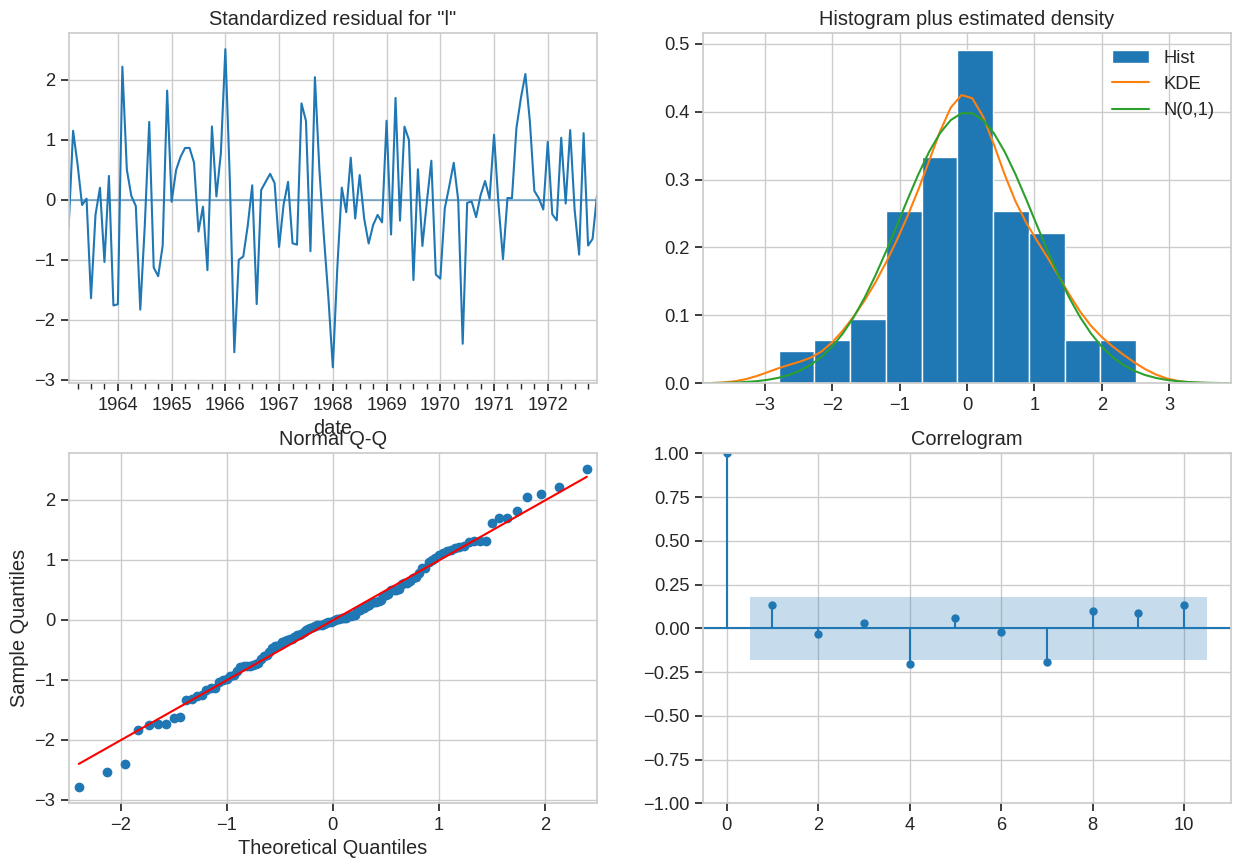

Ljung-Box test:
      lb_stat  lb_pvalue
24  27.126527    0.29859

Shapiro-Wilk test (p-value): 0.0000
Reject H0: residuals do not appear normally distributed.


In [82]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro

results.plot_diagnostics(figsize=(15, 10))
plt.show()

residuals = results.resid

# Ljung-Box test: H0 = residuals are white noise (no autocorrelation)
lb_result = acorr_ljungbox(residuals, lags=[24], return_df=True)
print("Ljung-Box test:")
print(lb_result)

# Normality check: H0 = residuals are normally distributed
stat, p_val = shapiro(residuals)
print(f"\nShapiro-Wilk test (p-value): {p_val:.4f}")
if p_val > 0.05:
    print("Cannot reject H0: residuals appear normally distributed.")
else:
    print("Reject H0: residuals do not appear normally distributed.")

### 4.2 Analisis Residuos Auto ARIMA

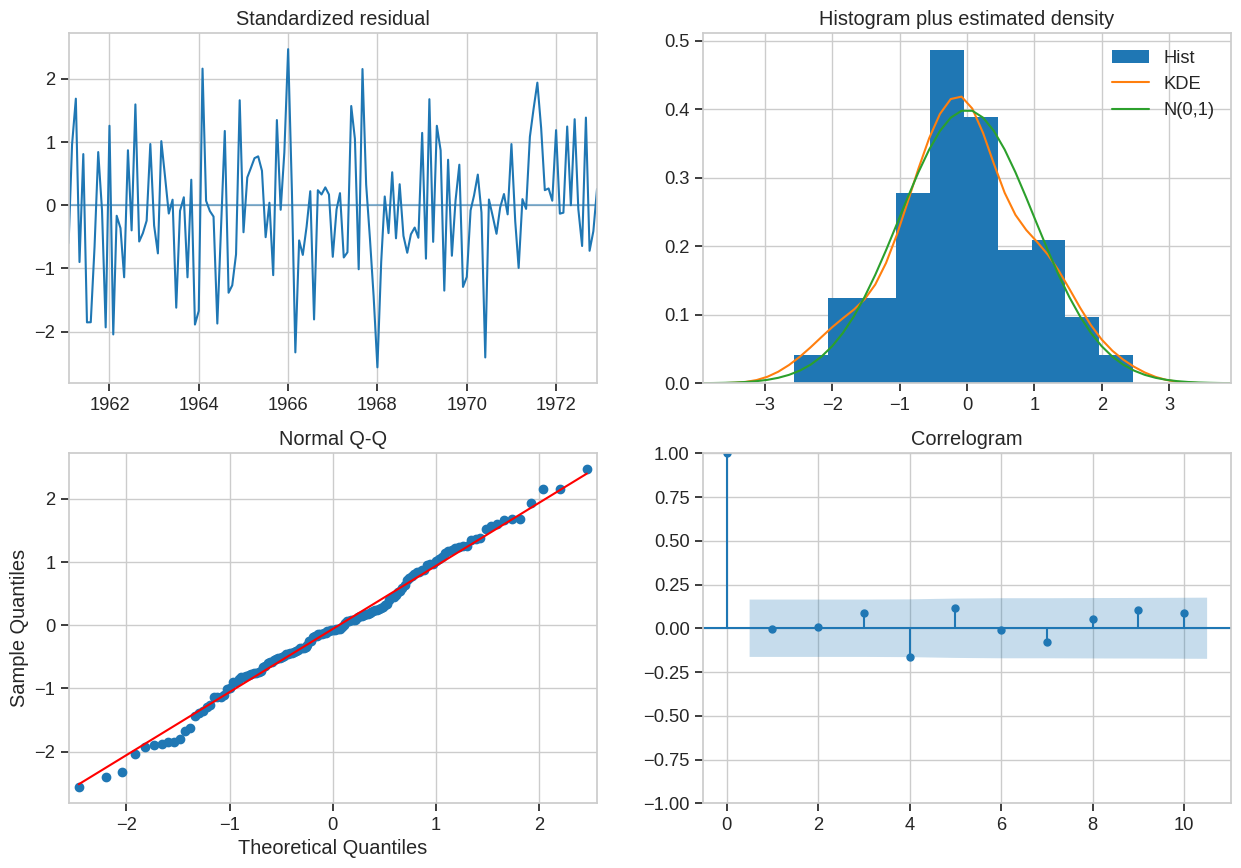

Ljung-Box test:
      lb_stat  lb_pvalue
24  36.360532   0.050619

Shapiro-Wilk test (p-value): 0.0000
Reject H0: residuals do not appear normally distributed.


In [83]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro

auto_model.plot_diagnostics(figsize=(15, 10))
plt.show()

residuals = auto_model.resid()

# Ljung-Box test: H0 = residuals are white noise (no autocorrelation)
lb_result = acorr_ljungbox(residuals, lags=[24], return_df=True)
print("Ljung-Box test:")
print(lb_result)

# Normality check: H0 = residuals are normally distributed
stat, p_val = shapiro(residuals)
print(f"\nShapiro-Wilk test (p-value): {p_val:.4f}")
if p_val > 0.05:
    print("Cannot reject H0: residuals appear normally distributed.")
else:
    print("Reject H0: residuals do not appear normally distributed.")

### Sin sentido:

All diagnostic plots show that the residuals are normally distributed over time (they look like white noise). However, The Ljung-Box test (p=0.051) barely fails to reject the white noise hypothesis, and Shapiro-Wilk flags non-normality (p≈0.000). Let's plot a non-estandarized QQ-Plot to further analyze this matter.

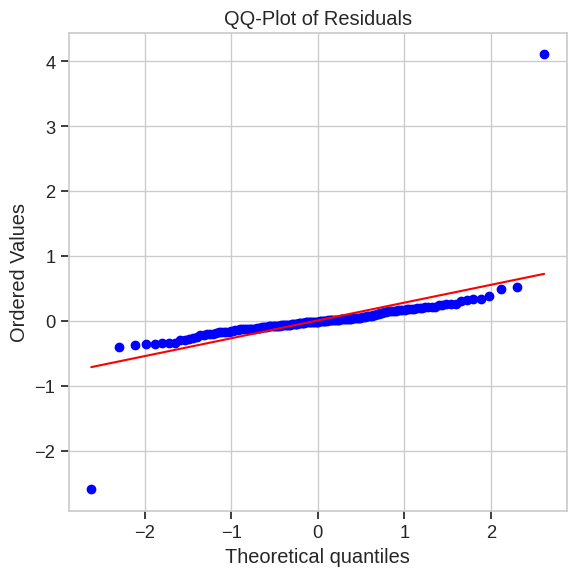

In [84]:
import scipy.stats as stats
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("QQ-Plot of Residuals")
plt.tight_layout()
plt.show()

Looking at this QQ-plot we can see that residuals follow the normal line closely, with the exception of two outliers pulling at both tails. These are the culprits behind the Shapiro-Wilk rejection, not a structural problem with the model. So we can conclude it is valid.

<span style="color: red">The initial points in the residuals series are not true outliers. In fact, residuals cannot be accurately calculated for the first $(D*m)+d$ time points because information is lost during the differencing process. Python typically pads these initial values to maintain the original length of the series rather than using NaN values. Consequently, these points are artifacts that should be removed from the residual analysis. As shown in the plots generated by the plot_diagnostics function, these points are excluded, allowing the residuals to follow a normal distribution properly. See also the code chuck give below to show the residual series</span>

Finally, we will project our predictions (Forecast) over the horizon of the Test set and compare numerical and visual metrics to evaluate its predictive performance.

<function matplotlib.pyplot.show(close=None, block=None)>

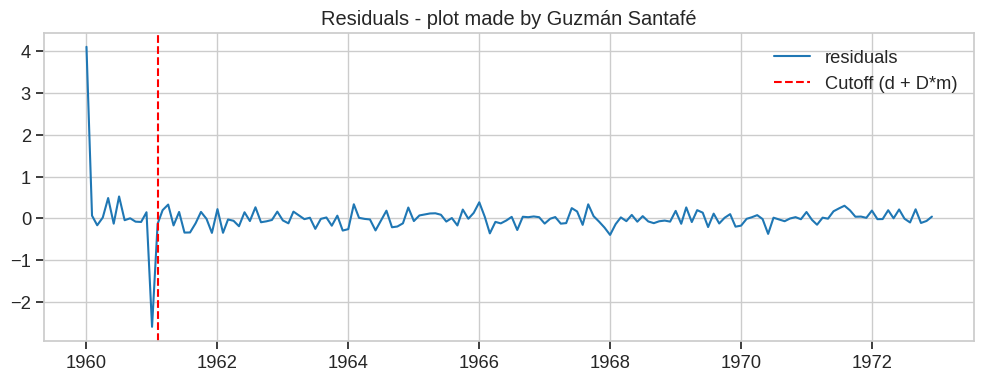

In [46]:
residuals = auto_model.resid()
plt.figure(figsize=(12, 4))
plt.plot(residuals, label='residuals')
plt.axvline(x=residuals.index[13], color='red', linestyle='--', label='Cutoff (d + D*m)')
plt.title('Residuals - plot made by Guzmán Santafé')
plt.legend()
plt.show

### 4.3 Predicciones Modelo Custom

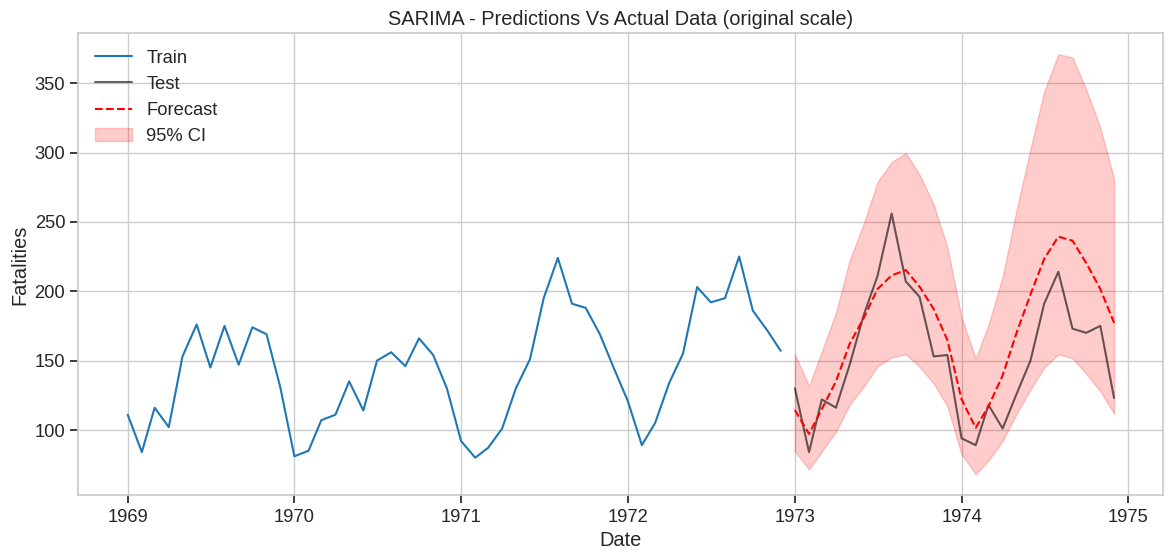

--- Predictive Performance Metrics ---
RMSE: 31.00
MAE:  25.43
MAPE: 17.67%


In [85]:
# statsmodels usa get_forecast(), no predict() con return_conf_int
forecast_obj = results.get_forecast(steps=len(test))
forecast_log = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int(alpha=0.05)

# Reverse log transform
pred_real = np.exp(forecast_log)
conf_int_real = np.exp(conf_int)
test_real = np.exp(test)

plt.figure(figsize=(14, 6))
train_real = np.exp(train)
plt.plot(train_real.index[-48:], train_real[-48:], label='Train')
plt.plot(test_real.index, test_real, label='Test', color='black', alpha=0.6)
plt.plot(test_real.index, pred_real, label='Forecast', color='red', linestyle='--')

plt.fill_between(test_real.index,
                 conf_int_real.iloc[:, 0],  # .iloc en vez de [:, 0]
                 conf_int_real.iloc[:, 1],
                 color='red', alpha=0.2, label='95% CI')

plt.title('SARIMA - Predictions Vs Actual Data (original scale)')
plt.xlabel('Date')
plt.ylabel('Fatalities')
plt.legend()
plt.show()

rmse = np.sqrt(mean_squared_error(test_real, pred_real))
mae = mean_absolute_error(test_real, pred_real)
mape = mean_absolute_percentage_error(test_real, pred_real)
print(f"--- Predictive Performance Metrics ---")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"MAPE: {mape*100:.2f}%")

### 4.4 Predicciones Auto ARIMA

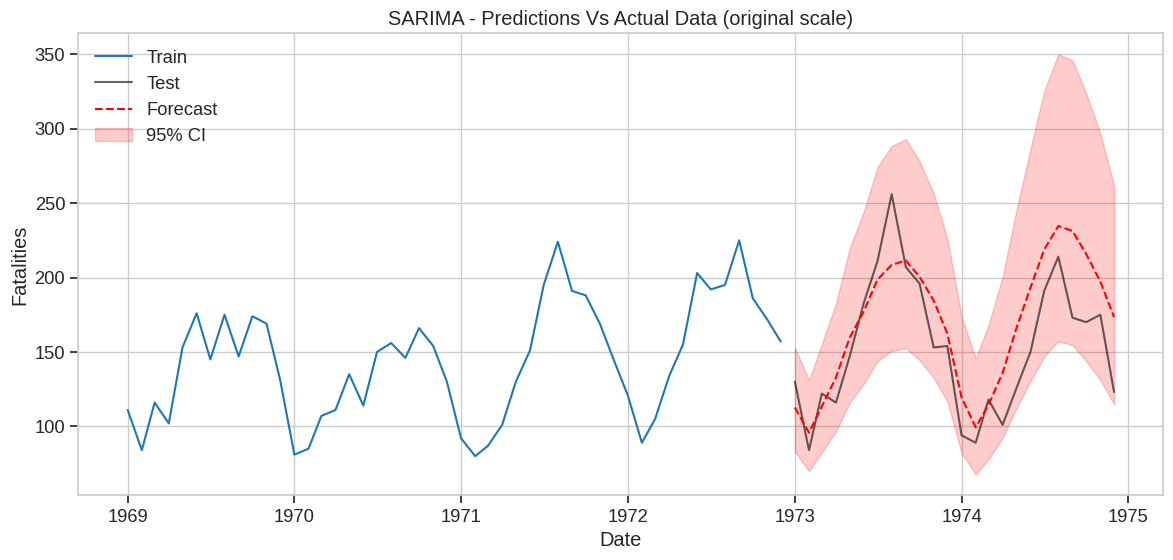

--- Predictive Performance Metrics ---
RMSE (Root Mean Squared Error): 28.66
MAE (Mean Absolute Error):      23.52
MAPE (Mean Absolute Pct Error): 16.31%


In [86]:
# Make predictions for the 24 periods (2 years) of the Test Set
forecast_log, conf_int = auto_model.predict(n_periods=len(test), return_conf_int=True, alpha=0.05)

# Reverse log transform
pred_real = np.exp(forecast_log)
conf_int_real = np.exp(conf_int)
test_real = np.exp(test)

plt.figure(figsize=(14, 6))
train_real = np.exp(train)
plt.plot(train_real.index[-48:], train_real[-48:], label='Train')
plt.plot(test_real.index, test_real, label='Test', color='black', alpha=0.6)
plt.plot(test_real.index, pred_real, label='Forecast', color='red', linestyle='--')

# Confidence interval
plt.fill_between(test_real.index, 
                 conf_int_real[:, 0], 
                 conf_int_real[:, 1], 
                 color='red', alpha=0.2, label='95% CI')

plt.title('SARIMA - Predictions Vs Actual Data (original scale)')
plt.xlabel('Date')
plt.ylabel('Fatalities')
plt.legend()
plt.show()

# Calculate performance metrics
rmse = np.sqrt(mean_squared_error(test_real, pred_real))
mae = mean_absolute_error(test_real, pred_real)
mape = mean_absolute_percentage_error(test_real, pred_real)

print(f"--- Predictive Performance Metrics ---")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"MAE (Mean Absolute Error):      {mae:.2f}")
print(f"MAPE (Mean Absolute Pct Error): {mape*100:.2f}%")

## 5. Conclusions

1. We have successfully preprocessed a dataset that contained monthly time gaps, interpolating the values continuously to preserve the statistical properties necessary for Time Series.
2. We identified in the EDA that we were dealing with a non-stationary series in mean (due to an increasing trend) and in variance (due to a scale effect). We managed to control this with a log transformation and by differencing the series (regular d=1 and seasonal D=1, m=12).
3. Using AutoARIMA, we selected the best SARIMA architecture: ARIMA(1,1,1)(2,1,0)[12]. The initial log transformation proved to be a wise decision, as it effectively stabilized the variance of the series.
4. Residual diagnostics showed that the model is statistically valid: the Ljung-Box test narrowly confirms the absence of autocorrelation, and while Shapiro-Wilk flags non-normality, the QQ-plot reveals this is driven by two isolated outliers rather than a structural issue. The model achieves a MAPE of 16.31% on the test set, capturing the seasonal pattern of summer peaks and winter drops in Ontario road fatalities.